# Open the box — Solutions


## Objectives

**Access the full data sample and estimate the number of signal events**

 * Consider the case of a counting experiment: estimate the number of signal events **in the RoI**, $n^{\beta\beta}_{RoI}$. 

 * Estimate the number of signal events, $n^{\beta\beta}_E$, **in the enlarged energy window**.

In both cases **set a limit or a confidence interval for $\mathcal{T}_{1/2}^{\beta\beta0\nu}$**.

**Also compute the p-value of the null hypothesis.**

## Analysis

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

#### Importing modules

In [2]:
import numpy  as np
import tables as tb
import pandas as pd
import matplotlib.pyplot as plt

import scipy.constants as constants
import scipy.stats     as stats
import scipy.optimize  as optimize

import warnings
warnings.filterwarnings('ignore')

In [3]:
import os, sys
from pathlib import Path

# Find the project root: honours FANAL_ROOT env-var, otherwise walks up from cwd
_env = os.environ.get('FANAL_ROOT') or os.environ.get('USCFANALDIR')
if _env and Path(_env, 'data').is_dir():
    rootpath = str(Path(_env).resolve())
else:
    rootpath = str(next(p for p in [Path.cwd(), *Path.cwd().parents]
                        if (p / 'data').is_dir() and (p / 'ana').is_dir()))
if rootpath not in sys.path:
    sys.path.insert(0, rootpath)
print('Fanal root : ', rootpath)

Fanal root :  /Users/hernando/work/docencia/FPII-fanal/USC-FPII-Fanal


In [4]:
import core.pltext  as pltext   # extensions for plotting histograms
import core.hfit    as hfit     # extension to fit histograms
import core.efit    as efit     # Fit Utilites - Includes Extend Likelihood Fit with composite PDFs
import core.utils   as ut       # generic utilities
import ana.fanal    as fn       # analysis functions specific to fanal
import     collpars as collpars # collaboration specific parameters
pltext.style()
import core.confint as confint  # Confidence Intervals
import ana.pltfanal as pltfn    # plotting for fanal

### Main Parameters

In [5]:
coll          = collpars.collaboration
sel_ntracks   = collpars.sel_ntracks
sel_eblob2    = collpars.sel_eblob2
sel_erange    = collpars.sel_erange
sel_eroi      = collpars.sel_eroi


print('Collaboration             : {:s}'.format(coll))
print('number of tracks range    : {:6d}'.format(sel_ntracks))
print('Blob-2 energy range       : {:6.3f}  MeV'.format(sel_eblob2))
print('Energy range              : ({:6.3f}, {:6.3f}) MeV'.format(*sel_erange))
print('Energy RoI range          : ({:6.3f}, {:6.3f}) MeV'.format(*sel_eroi))

Collaboration             : new_beta
number of tracks range    :      1
Blob-2 energy range       :  0.400  MeV
Energy range              : ( 2.400,  2.700) MeV
Energy RoI range          : ( 2.430,  2.480) MeV


In [6]:
n_Bi_RoI  = collpars.n_Bi_RoI
n_Tl_RoI  = collpars.n_Tl_RoI
n_Bi_E    = collpars.n_Bi_E
n_Tl_E    = collpars.n_Tl_E

print('Number Bi events in RoI = {:6.3f}'.format(n_Bi_RoI))
print('Number Tl events in RoI = {:6.3f}'.format(n_Tl_RoI))
print('Number Bi events in E   = {:6.3f}'.format(n_Bi_E))
print('Number Tl events in E   = {:6.3f}'.format(n_Tl_E))

Number Bi events in RoI = 21.732
Number Tl events in RoI =  4.009
Number Bi events in E   = 25.238
Number Tl events in E   = 150.851


In [7]:
# Background estimates
n_bkg_RoI = n_Bi_RoI + n_Tl_RoI
n_bkg_E   = n_Bi_E   + n_Tl_E

# Signal efficiencies and exposure
eff_bb_E   = collpars.eff_bb_E
eff_bb_RoI = collpars.eff_bb_RoI
exposure   = collpars.exposure     # kg * y

print('Expected bkg in RoI      = {:6.2f}'.format(n_bkg_RoI))
print('Expected bkg in E window = {:6.2f}'.format(n_bkg_E))
print('Signal eff in E window   = {:6.4f}'.format(eff_bb_E))
print('Signal eff in RoI        = {:6.4f}'.format(eff_bb_RoI))
print('Exposure                 = {:6.0f} kg y'.format(exposure))

Expected bkg in RoI      =  25.74
Expected bkg in E window = 176.09
Signal eff in E window   = 0.5190
Signal eff in RoI        = 0.5190
Exposure                 =   1000 kg y


## Before you open the box...

You are about to access the data in the RoI for the first time.
This is the moment of truth in a blind analysis!

**But before that**: do you have a clear plan of what to do with the data?

Write down a list of the steps you will follow once the box is open:
- What will you compute first?
- What plots will you make?
- How will you decide if you see a signal or not?
- What result will you report: a measurement or a limit?

**Discuss your plan with the professor before proceeding!**

Once you have a clear plan, continue to the next cell to access the full data.

## Access the full data

We access the **full data sample** by concatenating the blind data and the RoI data.
Until now we only had access to the blind sample; this is the moment we "open the box".

In [8]:
dirpath  = rootpath + '/data/'
filename = 'fanal_' + coll + '.h5'
print('Data path:', dirpath + filename)

Data path: /Users/hernando/work/docencia/FPII-fanal/USC-FPII-Fanal/data/fanal_new_beta.h5


In [9]:
# Load blind + RoI data and concatenate into the full data set
datab = pd.read_hdf(dirpath + filename, key = 'data/blind').fillna(0.)
datar = pd.read_hdf(dirpath + filename, key = 'data/roi').fillna(0.)
data  = pd.concat((datab, datar))

print('Blind events : {:d}'.format(len(datab)))
print('RoI events   : {:d}'.format(len(datar)))
print('Total events : {:d}'.format(len(data)))

Blind events : 21566
RoI events   : 497
Total events : 22063


### Visualise the full energy spectrum

Plot the energy of all events before any selection, then apply the selection cuts progressively.

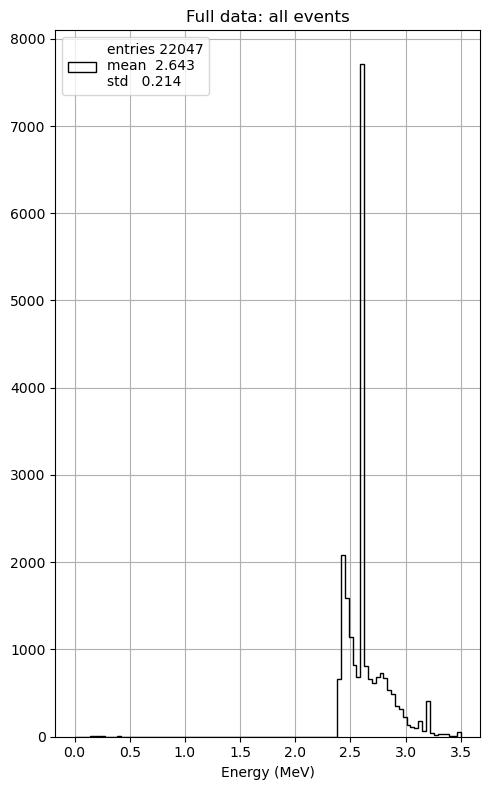

In [10]:
# Plot the raw energy spectrum of all events
pltext.canvas(1, 1, 8, 5)
pltext.hist(data.E, 100, range=(0, 3.5))
plt.xlabel('Energy (MeV)')
plt.title('Full data: all events')
plt.tight_layout()

### Apply the signal selection

Apply the selection cuts step by step (as defined in the first notebook) and
visualise how the energy spectrum changes.

Remember the selection:
1. `num_tracks == 1`
2. `blob2_E > sel_eblob2`
3. Energy in range `sel_erange`
4. Energy in RoI `sel_eroi` (for the counting experiment)

In [11]:
# Apply selection cuts progressively
mask_erange  = (data.E >= sel_erange[0]) & (data.E < sel_erange[1])
mask_ntracks = mask_erange & (data.num_tracks <= sel_ntracks)
mask_blob2   = mask_ntracks & (data.blob2_E >= sel_eblob2)
mask_roi     = mask_blob2  & (data.E >= sel_eroi[0]) & (data.E < sel_eroi[1])

print('Events in energy range           : {:d}'.format(mask_erange.sum()))
print('  + 1 track                      : {:d}'.format(mask_ntracks.sum()))
print('  + blob2 cut                    : {:d}'.format(mask_blob2.sum()))
print('  + in RoI                       : {:d}'.format(mask_roi.sum()))

Events in energy range           : 16157
  + 1 track                      : 1062
  + blob2 cut                    : 171
  + in RoI                       : 36


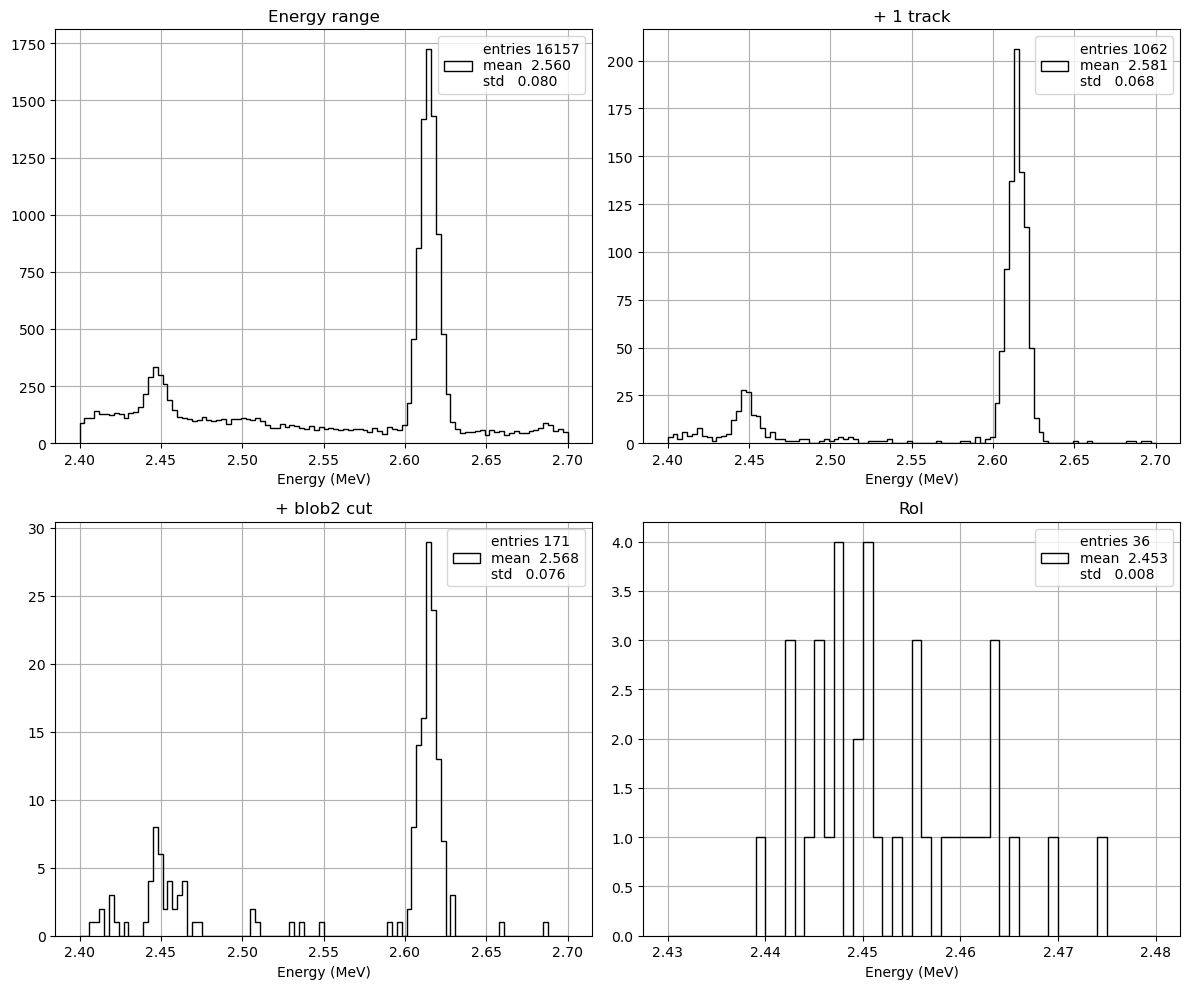

In [12]:
# Plot the energy distribution at each selection step
subplot = pltext.canvas(4)

subplot(1)
pltext.hist(data.E[mask_erange], 100, range=sel_erange)
plt.xlabel('Energy (MeV)'); plt.title('Energy range')

subplot(2)
pltext.hist(data.E[mask_ntracks], 100, range=sel_erange)
plt.xlabel('Energy (MeV)'); plt.title('+ 1 track')

subplot(3)
pltext.hist(data.E[mask_blob2], 100, range=sel_erange)
plt.xlabel('Energy (MeV)'); plt.title('+ blob2 cut')

subplot(4)
pltext.hist(data.E[mask_roi], 50, range=sel_eroi)
plt.xlabel('Energy (MeV)'); plt.title('RoI')

plt.tight_layout()

---

## Analysis A: Counting experiment in the RoI

In the counting experiment approach, we simply count the number of events
that pass all selection cuts and fall in the RoI.

The number of **signal** events is estimated as:

$$
n^{\beta\beta}_{RoI} = n_{obs} - n^{bkg}_{RoI}
$$

where $n_{obs}$ is the number of observed events in the RoI, and $n^{bkg}_{RoI}$
is the expected number of background events (estimated from the blind analysis).

In [13]:
# Count events in the RoI
n_obs_RoI = int(mask_roi.sum())

# Estimated signal events
n_signal_RoI = n_obs_RoI - n_bkg_RoI

print('Observed events in RoI        : {:d}'.format(n_obs_RoI))
print('Expected background in RoI    : {:.2f}'.format(n_bkg_RoI))
print('Estimated signal in RoI       : {:.2f}'.format(n_signal_RoI))

Observed events in RoI        : 36
Expected background in RoI    : 25.74
Estimated signal in RoI       : 10.26


### Feldman-Cousins confidence interval

Using the Feldman-Cousins method (as practised in the sensitivity notebook),
compute the confidence interval on the number of signal events.

In [14]:
# Feldman-Cousins confidence interval for the counting experiment
nus = np.linspace(0., max(3 * n_bkg_RoI, 30.), 300)
ns  = np.arange(0, int(3 * n_bkg_RoI) + 20)

fc_95 = confint.get_fc_confinterval(nus, n_bkg_RoI, cl=0.95)
fc_68 = confint.get_fc_confinterval(nus, n_bkg_RoI, cl=0.68)

ci_95 = fc_95(n_obs_RoI)
ci_68 = fc_68(n_obs_RoI)

print('Observed n = {:d},  expected bkg = {:.2f}'.format(n_obs_RoI, n_bkg_RoI))
print('FC CI on signal at 68% CL: ({:.2f}, {:.2f})'.format(*ci_68))
print('FC CI on signal at 95% CL: ({:.2f}, {:.2f})'.format(*ci_95))

Observed n = 36,  expected bkg = 25.74
FC CI on signal at 68% CL: (4.65, 17.05)
FC CI on signal at 95% CL: (1.03, 23.50)


### Half-life from the counting experiment

Translate the signal confidence interval into a half-life limit or measurement.

In [15]:
# Half-life from counting experiment
if ci_95[0] <= 0:
    # Signal consistent with zero: report upper limit on signal -> lower limit on half-life
    n_signal_upper_95 = ci_95[1]
    tau_limit_95 = fn.half_life(n_signal_upper_95, exposure, eff_bb_RoI)
    print('Signal upper limit (95% CL): {:.2f} events'.format(n_signal_upper_95))
    print('Half-life lower limit (95% CL): {:.2e} years'.format(tau_limit_95))
else:
    # Signal significantly positive: report measurement
    n_signal_est = n_signal_RoI
    tau_est = fn.half_life(n_signal_est, exposure, eff_bb_RoI)
    tau_lo  = fn.half_life(ci_68[1], exposure, eff_bb_RoI)
    tau_hi  = fn.half_life(ci_68[0], exposure, eff_bb_RoI)
    print('Signal estimate: {:.2f} events'.format(n_signal_est))
    print('Half-life: {:.2e} ({:.2e}, {:.2e}) years'.format(tau_est, tau_lo, tau_hi))


Signal estimate: 10.26 events
Half-life: 1.40e+26 (8.42e+25, 3.09e+26) years


---

## Analysis B: Extended likelihood fit in the energy window

The fit approach uses the full energy distribution in the enlarged energy window
to simultaneously estimate the number of Bi, Tl, and $\beta\beta0\nu$ events.

This is more powerful than the counting experiment because it uses the **shape** of
the energy distribution, not just the total count.

In [16]:
# Load MC samples for the fit templates
mcbi = pd.read_hdf(dirpath + filename, key = 'mc/bi214').fillna(0.)
mctl = pd.read_hdf(dirpath + filename, key = 'mc/tl208').fillna(0.)
mcbb = pd.read_hdf(dirpath + filename, key = 'mc/bb0nu').fillna(0.)

mc_samples         = [mcbi, mctl, mcbb]
sample_names       = ['Bi', 'Tl', 'bb']
sample_names_latex = [r'$^{214}$Bi', r'$^{208}$Tl', r'$\beta\beta0\nu$']

# Define selection variable names and ranges (same as in fanal_signal notebook)
ntracks_range = (sel_ntracks, sel_ntracks + 0.1)
eblob2_range  = (sel_eblob2, sel_erange[1])

varnames  = ['num_tracks', 'blob2_E', 'E']
varranges = [ntracks_range, eblob2_range, sel_erange]

refnames  = ['num_tracks', 'E']
refranges = [ntracks_range, sel_erange]

### Fit the full data

We prepare the extended likelihood fit and apply it to the full data sample.
The fit estimates the number of events of each component (Bi, Tl, $\beta\beta0\nu$).

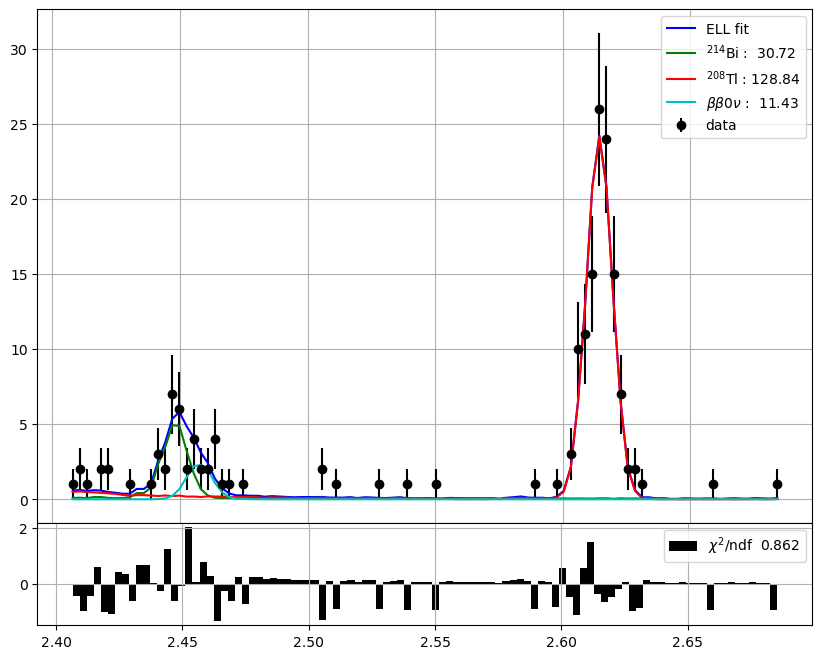

In [17]:
# Prepare and run the extended likelihood fit
n_guess = [n_Bi_E, n_Tl_E, 1.]

fit = fn.prepare_fit_ell(mc_samples, n_guess, varnames, varranges, refnames, refranges)
result, values, ell, _ = fit(data)
n_est = result.x

pltfn.plot_fit_ell(values, n_est, ell, parnames = sample_names_latex);


In [18]:
# Print fitted event counts
for i, name in enumerate(sample_names_latex):
    print('{:s}: {:.2f} events'.format(name, n_est[i]))
print()
print('Fitted signal events: {:.2f}'.format(n_est[2]))
print('Expected background:  Bi = {:.2f}, Tl = {:.2f}'.format(n_Bi_E, n_Tl_E))


$^{214}$Bi: 30.72 events
$^{208}$Tl: 128.84 events
$\beta\beta0\nu$: 11.43 events

Fitted signal events: 11.43
Expected background:  Bi = 25.24, Tl = 150.85


### Parameter uncertainties (profile likelihood scan)

Perform a profile likelihood scan to estimate the uncertainties on the
fitted parameters, especially the number of signal events.

$^{214}$Bi: 30.72  (-6.11, +7.01)  at 68% CL
$^{208}$Tl: 128.84  (-10.66, +11.58)  at 68% CL
$\beta\beta0\nu$: 11.43  (-4.00, +4.55)  at 68% CL


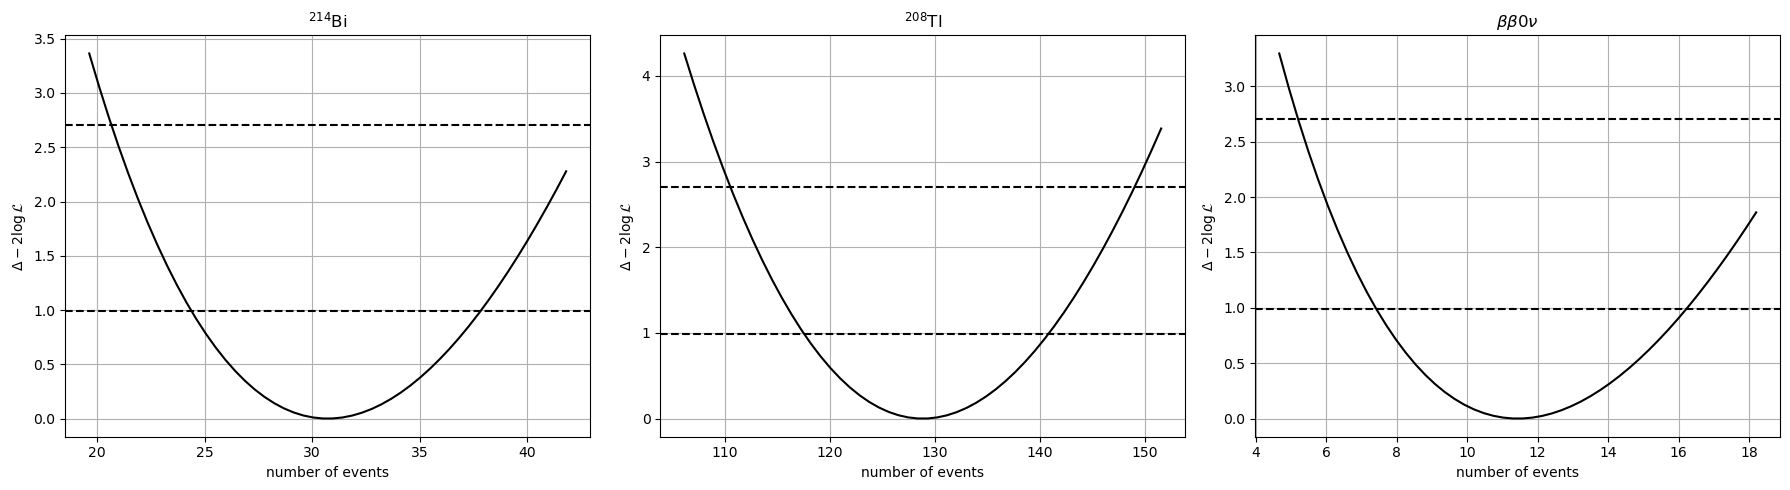

In [19]:
# Profile likelihood scan
nis, tmus = fn.tmu_scan(values, n_est, ell, sizes = (2., 2., 2.))
pltfn.plot_tmu_scan(nis, tmus, titles = sample_names_latex)

cl = 0.68
mucis = [efit.tmu_conf_int(ni, tmu, cl) for ni, tmu in zip(nis, tmus)]
for i, ci in enumerate(mucis):
    print('{:s}: {:.2f}  ({:.2f}, +{:.2f})  at {:d}% CL'.format(
        sample_names_latex[i], n_est[i], ci[0] - n_est[i], ci[1] - n_est[i], int(100 * cl)))


### p-value of the null hypothesis

Compute the p-value of the no-signal hypothesis using the profile likelihood
ratio test statistic $q_0$:

$$
q_0 = -2 \log \frac{\mathcal{L}(\text{data} \,|\, n_{\beta\beta} = 0, \hat{\hat{\mathbf{n}}}_{bkg})}{\mathcal{L}(\text{data} \,|\, \hat{n}_{\beta\beta}, \hat{\mathbf{n}}_{bkg})}
$$

Under the null hypothesis, $q_0$ follows a $\chi^2(1)/2$ distribution.
The p-value is $p_0 = 1 - \Phi(\sqrt{q_0})$.

In [20]:
# p-value of the null hypothesis
q0 = efit.tmu(values, ell, result.x, 0, ipos = 2)
z0 = np.sqrt(q0)
p0 = 1 - stats.norm.cdf(z0)

print('q0        = {:.2f}'.format(q0))
print('Z0        = {:.2f} sigma'.format(z0))
print('p-value   = {:.2e}'.format(p0))
print()
if z0 >= 5:
    print('=> Discovery! (>= 5 sigma)')
elif z0 >= 3:
    print('=> Evidence (>= 3 sigma)')
else:
    print('=> No significant signal (< 3 sigma)')


q0        = 14.12
Z0        = 3.76 sigma
p-value   = 8.59e-05

=> Evidence (>= 3 sigma)


---

## Half-life estimation

Translate your results (from both the counting experiment and the fit) into
a half-life measurement or limit.

Recall the formula:

$$
\mathcal{T}_{1/2}^{\beta\beta0\nu} = \frac{\delta \, \epsilon \, M \, t}{n^{\beta\beta}} \frac{N_A \, \ln 2}{W}
$$

Use `fn.half_life(nbb, exposure, eff)` or implement it directly.

In [21]:
# Half-life from both analyses
print('=== A) Counting experiment ===')
print('Signal in RoI: {:.2f} events'.format(n_signal_RoI))
print('FC 95% CI: ({:.2f}, {:.2f})'.format(*ci_95))
if ci_95[0] <= 0:
    tau_limit = fn.half_life(ci_95[1], exposure, eff_bb_RoI)
    print('Half-life lower limit (95%): {:.2e} years'.format(tau_limit))
else:
    tau_est = fn.half_life(n_signal_RoI, exposure, eff_bb_RoI)
    print('Half-life: {:.2e} years'.format(tau_est))

print()
print('=== B) Extended likelihood fit ===')
n_bb_fit = n_est[2]
ci_bb_68 = mucis[2]
print('Signal events: {:.2f}  ({:.2f}, +{:.2f})'.format(
    n_bb_fit, ci_bb_68[0] - n_bb_fit, ci_bb_68[1] - n_bb_fit))

if ci_bb_68[0] <= 0:
    tau_limit = fn.half_life(ci_bb_68[1], exposure, eff_bb_E)
    print('Half-life lower limit (68%): {:.2e} years'.format(tau_limit))
else:
    tau_est = fn.half_life(n_bb_fit, exposure, eff_bb_E)
    tau_lo  = fn.half_life(ci_bb_68[1], exposure, eff_bb_E)
    tau_hi  = fn.half_life(ci_bb_68[0], exposure, eff_bb_E)
    print('Half-life: {:.2e} ({:.2e}, {:.2e}) years'.format(tau_est, tau_lo, tau_hi))


=== A) Counting experiment ===
Signal in RoI: 10.26 events
FC 95% CI: (1.03, 23.50)
Half-life: 1.40e+26 years

=== B) Extended likelihood fit ===
Signal events: 11.43  (-4.00, +4.55)
Half-life: 1.25e+26 (8.97e+25, 1.93e+26) years


### Write final results to collpars

In [22]:
# Append final results to collpars.py
write = True
collpar_filename = "collpars.py"
if (write):
    of = open(collpar_filename, 'a')
    of.write('n_obs_RoI       = {:d}\n'.format(n_obs_RoI))
    of.write('n_signal_RoI    = {:6.3f}\n'.format(n_signal_RoI))
    of.write('n_bb_fit        = {:6.3f}\n'.format(n_bb_fit))
    of.write('z0              = {:6.2f} # sigma\n'.format(z0))
    of.write('p_value         = {:.2e}\n'.format(p0))
    # FC confidence intervals on signal (counting)
    of.write('ci_68_count     = ({:.2f}, {:.2f})\n'.format(*ci_68))
    of.write('ci_95_count     = ({:.2f}, {:.2f})\n'.format(*ci_95))
    # Profile likelihood CI on signal (fit)
    of.write('ci_68_fit       = ({:.2f}, {:.2f})\n'.format(*ci_bb_68))
    # Half-life from counting experiment
    tau_count = fn.half_life(n_signal_RoI, exposure, eff_bb_RoI)
    of.write('half_life_count = {:.2e} # y\n'.format(tau_count))
    # Half-life CI from counting (FC 68%)
    tau_count_lo = fn.half_life(ci_68[1], exposure, eff_bb_RoI)
    tau_count_hi = fn.half_life(max(ci_68[0], 1e-10), exposure, eff_bb_RoI)
    of.write('half_life_count_lo = {:.2e} # y, FC 68% lower\n'.format(tau_count_lo))
    of.write('half_life_count_hi = {:.2e} # y, FC 68% upper\n'.format(tau_count_hi))
    # Half-life from fit
    tau_fit = fn.half_life(n_bb_fit, exposure, eff_bb_E)
    of.write('half_life_fit   = {:.2e} # y\n'.format(tau_fit))
    # Half-life CI from fit (profile likelihood 68%)
    tau_fit_lo = fn.half_life(ci_bb_68[1], exposure, eff_bb_E)
    tau_fit_hi = fn.half_life(max(ci_bb_68[0], 1e-10), exposure, eff_bb_E)
    of.write('half_life_fit_lo = {:.2e} # y, profile 68% lower\n'.format(tau_fit_lo))
    of.write('half_life_fit_hi = {:.2e} # y, profile 68% upper\n'.format(tau_fit_hi))
    of.close()
    print('Final results appended to', collpar_filename)

Final results appended to collpars.py


---

## Summary

Fill in the table below with your results:

| | Counting experiment | Extended likelihood fit |
|---|---|---|
| Observed / Estimated signal events | | |
| Signal CI at 95% CL | | |
| p-value (significance) | | |
| $\mathcal{T}_{1/2}^{\beta\beta0\nu}$ (y) or limit | | |

**Conclusions:**
- Is there evidence for a signal in your data?
- Is the result a measurement or a limit?
- How do the two analysis methods compare?

These results will form the core of your oral presentation and article.